In [1]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")

In [2]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
from ML_amber import TwoLens1S
from ML_amber import ThreeLens1S

## Set Up of "Standard" System

In [3]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.0155] #paper

u0_list_n = [-0.0155]

t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 1000

#paper
D_l = 6 #kpc
D_s = 8 #kpc

m1 = 0.3 #Lens Star Mass (Solar Mass)

In [4]:
def Einstein_Radius(M_solar, D_l_kpc, D_s_kpc):
    """
    Computes the Einstein Radius.

    Parameters:
    M_solar : float
        Mass of the lens in Solar masses
    D_l_kpc : float
        Distance to the lens in kpc
    D_s_kpc : float
        Distance to the source in kpc

    Returns:
    R_E : float
        Einstein radius in meters
    theta_E_arcsec : float
        Einstein radius in arcseconds
    theta_E_mas : float
        Einstein radius in milliarcseconds
    """
    # Constants
    c = 3e8            # speed of light in m/s
    G = 6.674e-11      # gravitational constant in N m^2 / kg^2
    M_sun = 1.989e30   # kg
    kpc_to_m = 3.086e19  # meters
    rad_to_arcsec = 206265  # arcsec per radian

    # Convert inputs
    M = M_solar * M_sun
    D_l = D_l_kpc * kpc_to_m
    D_s = D_s_kpc * kpc_to_m
    D_ls = D_s - D_l

    # Einstein radius in meters
    R_E = ((4 * G * M / c**2) * (D_ls * D_l / D_s)) ** 0.5

    # Angular Einstein radius in radians
    theta_E_rad = R_E / D_l

    # Convert to arcsec and mas
    theta_E_arcsec = theta_E_rad * rad_to_arcsec
    theta_E_mas = theta_E_arcsec * 1000

    return R_E, theta_E_arcsec, theta_E_mas


In [5]:
R_E, theta_E_arcsec, theta_E_mas = Einstein_Radius(m1, D_l, D_s)

print(f"Einstein Radius: {R_E:.2e} m")
print(f"Angular Einstein Radius: {theta_E_arcsec:.4f} arcsec")
print(f"Angular Einstein Radius: {theta_E_mas:.2f} mas")

Einstein Radius: 2.86e+11 m
Angular Einstein Radius: 0.0003 arcsec
Angular Einstein Radius: 0.32 mas


In [6]:
def Moon_Geometry(s2, d, phi_deg):
    """
    Compute s3 and psi given planet position s2, planet-moon distance d,
    and angle phi (degrees) measured from the star-planet axis.
    
    Returns
    -------
    s3 : float
        Star-moon separation (in Einstein radius units)
    psi : float
        Angle of moon relative to x-axis (radians)
    """
    phi = np.radians(phi_deg)
    x_m = s2 + d * np.cos(phi)
    y_m = d * np.sin(phi)
    
    s3 = np.sqrt(x_m**2 + y_m**2)
    psi_deg = np.degrees(np.arctan2(y_m, x_m))
    return s3, psi_deg


# Changing Position of Moon

In [56]:
angles = [0, 45, 90, 135, 180, 225, 270, 315]

s2 = 1.3   # star-planet distance
d = 0.0315   # planet-moon distance

results = []
for phi in angles:
    s3, psi = Moon_Geometry(s2, d, phi)
    results.append((phi, s3, psi))

for phi, s3, psi in results:
    print(f"phi = {phi}° -> s3 = {s3:.5f}, psi = {psi:.2f}°")

phi = 0° -> s3 = 1.33150, psi = 0.00°
phi = 45° -> s3 = 1.32246, psi = 0.97°
phi = 90° -> s3 = 1.30038, psi = 1.39°
phi = 135° -> s3 = 1.27792, psi = 1.00°
phi = 180° -> s3 = 1.26850, psi = 0.00°
phi = 225° -> s3 = 1.27792, psi = -1.00°
phi = 270° -> s3 = 1.30038, psi = -1.39°
phi = 315° -> s3 = 1.32246, psi = -0.97°


In [7]:
s3_1 = 1.33150
s3_2 = 1.32246
s3_3 = 1.30038
s3_4 = 1.27792
s3_5 = 1.26850
s3_6 = 1.27792
s3_7 = 1.30038
s3_8 = 1.32246

psi_1 = 0.00
psi_2 = 0.97
psi_3 = 1.39
psi_4 = 1.00
psi_5 = 0
psi_6 = -1.00
psi_7 = -1.39
psi_8 = -0.97

In [92]:
ex1_m = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_1, 5, psi_1, rs, secnum, basenum, num_points)

param = [
    np.log(ex1_m.s2), np.log(ex1_m.q2), ex1_m.u0_list[0], ex1_m.alpha_deg,
    np.log(ex1_m.rho), np.log(ex1_m.tE), ex1_m.t0,
    np.log(ex1_m.s3), np.log(ex1_m.q3), ex1_m.psi_rad
]
mag, *_ = ex1_m.VBM.TripleLightCurve(param, ex1_m.highres_t)


three_system = ex1_m.systems[0]

delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

u0=0.0155 VB y1[:5]=[1.99374031 1.9837534  1.97376648 1.96377957 1.95379265] y2[:5]=[0.15887047 0.15799673 0.15712298 0.15624924 0.1553755 ]
u0=0.0155 analytic y1[:5]=[1.99374031 1.9837534  1.97376648 1.96377957 1.95379265] y2[:5]=[0.15887047 0.15799673 0.15712298 0.15624924 0.1553755 ]


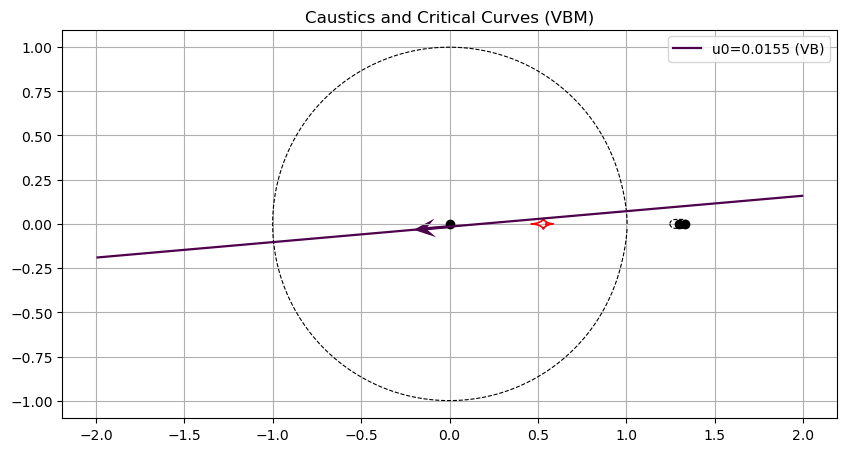

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Caustics and Critical Curves (VBM)'}>)

In [93]:
ex1_m.plot_caustics_and_critical()

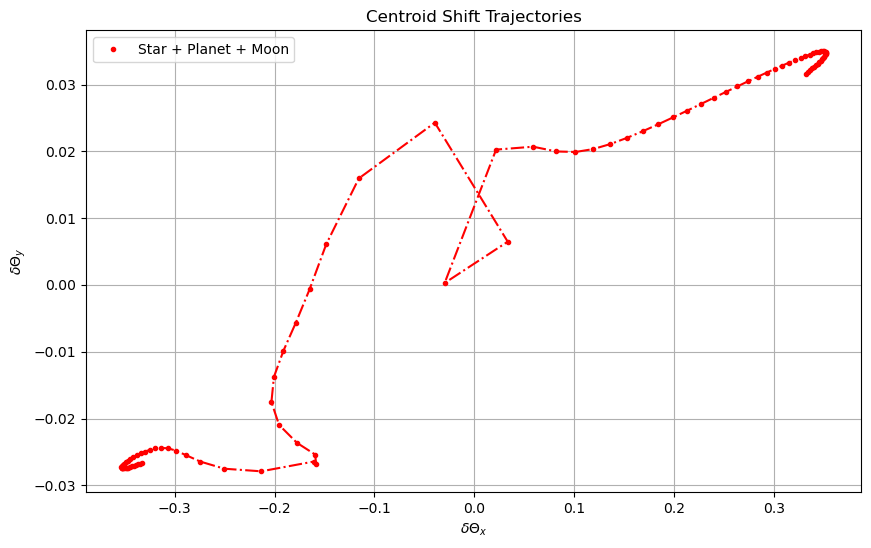

In [94]:
#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [105]:
ex1_bin = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 5, t_lc= ex1_m.highres_t)
two_system = ex1_bin.systems[0]
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_y_two = -delta_y_two

In [96]:
ex2 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_2, 5, psi_2, rs, secnum, basenum, num_points)

param = [
    np.log(ex2.s2), np.log(ex2.q2), ex2.u0_list[0], ex2.alpha_deg,
    np.log(ex2.rho), np.log(ex2.tE), ex2.t0,
    np.log(ex2.s3), np.log(ex2.q3), ex2.psi_rad
]
mag, *_ = ex2.VBM.TripleLightCurve(param, ex2.highres_t)

three_system2 = ex2.systems[0]

delta_x_three2 = three_system2['cent_x'] - three_system2['y1s']
delta_y_three2 = three_system2['cent_y'] - three_system2['y2s']

delta_x_three2 = - delta_x_three2
delta_y_three2 = delta_y_three2

In [97]:
ex3 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_3, 5, psi_3, rs, secnum, basenum, num_points)

param = [
    np.log(ex3.s2), np.log(ex3.q2), ex3.u0_list[0], ex3.alpha_deg,
    np.log(ex3.rho), np.log(ex3.tE), ex3.t0,
    np.log(ex3.s3), np.log(ex3.q3), ex3.psi_rad
]
mag, *_ = ex3.VBM.TripleLightCurve(param, ex3.highres_t)

three_system3 = ex3.systems[0]

delta_x_three3 = three_system3['cent_x'] - three_system3['y1s']
delta_y_three3 = three_system3['cent_y'] - three_system3['y2s']

delta_x_three3 = - delta_x_three3
delta_y_three3 = delta_y_three3

In [98]:
ex4 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_4, 5, psi_4, rs, secnum, basenum, num_points)

param = [
    np.log(ex4.s2), np.log(ex4.q2), ex4.u0_list[0], ex4.alpha_deg,
    np.log(ex4.rho), np.log(ex4.tE), ex4.t0,
    np.log(ex4.s3), np.log(ex4.q3), ex4.psi_rad
]
mag, *_ = ex4.VBM.TripleLightCurve(param, ex4.highres_t)

three_system4 = ex4.systems[0]

delta_x_three4 = three_system4['cent_x'] - three_system4['y1s']
delta_y_three4 = three_system4['cent_y'] - three_system4['y2s']

delta_x_three4 = - delta_x_three4
delta_y_three4 = delta_y_three4

In [99]:
ex5 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_5, 5, psi_5, rs, secnum, basenum, num_points)

param = [
    np.log(ex5.s2), np.log(ex5.q2), ex5.u0_list[0], ex5.alpha_deg,
    np.log(ex5.rho), np.log(ex5.tE), ex5.t0,
    np.log(ex5.s3), np.log(ex5.q3), ex5.psi_rad
]
mag, *_ = ex5.VBM.TripleLightCurve(param, ex5.highres_t)

three_system5 = ex5.systems[0]

delta_x_three5 = three_system5['cent_x'] - three_system5['y1s']
delta_y_three5 = three_system5['cent_y'] - three_system5['y2s']

delta_x_three5 = - delta_x_three5
delta_y_three5 = delta_y_three5

In [100]:
ex6 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_6, 5, psi_6, rs, secnum, basenum, num_points)

param = [
    np.log(ex6.s2), np.log(ex6.q2), ex6.u0_list[0], ex6.alpha_deg,
    np.log(ex6.rho), np.log(ex6.tE), ex6.t0,
    np.log(ex6.s3), np.log(ex6.q3), ex6.psi_rad
]
mag, *_ = ex6.VBM.TripleLightCurve(param, ex6.highres_t)

three_system6 = ex6.systems[0]

delta_x_three6 = three_system6['cent_x'] - three_system6['y1s']
delta_y_three6 = three_system6['cent_y'] - three_system6['y2s']

delta_x_three6 = - delta_x_three6
delta_y_three6 = delta_y_three6

In [101]:
ex7 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_7, 5, psi_7, rs, secnum, basenum, num_points)

param = [
    np.log(ex7.s2), np.log(ex7.q2), ex7.u0_list[0], ex7.alpha_deg,
    np.log(ex7.rho), np.log(ex7.tE), ex7.t0,
    np.log(ex7.s3), np.log(ex7.q3), ex7.psi_rad
]
mag, *_ = ex7.VBM.TripleLightCurve(param, ex7.highres_t)

three_system7 = ex7.systems[0]

delta_x_three7 = three_system7['cent_x'] - three_system7['y1s']
delta_y_three7 = three_system7['cent_y'] - three_system7['y2s']

delta_x_three7 = - delta_x_three7
delta_y_three7 = delta_y_three7

In [102]:
ex8 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_8, 5, psi_8, rs, secnum, basenum, num_points)

param = [
    np.log(ex8.s2), np.log(ex8.q2), ex8.u0_list[0], ex8.alpha_deg,
    np.log(ex8.rho), np.log(ex8.tE), ex8.t0,
    np.log(ex8.s3), np.log(ex8.q3), ex8.psi_rad
]
mag, *_ = ex8.VBM.TripleLightCurve(param, ex8.highres_t)

three_system8 = ex8.systems[0]

delta_x_three8 = three_system8['cent_x'] - three_system8['y1s']
delta_y_three8 = three_system8['cent_y'] - three_system8['y2s']

delta_x_three8 = - delta_x_three8
delta_y_three8 = delta_y_three8

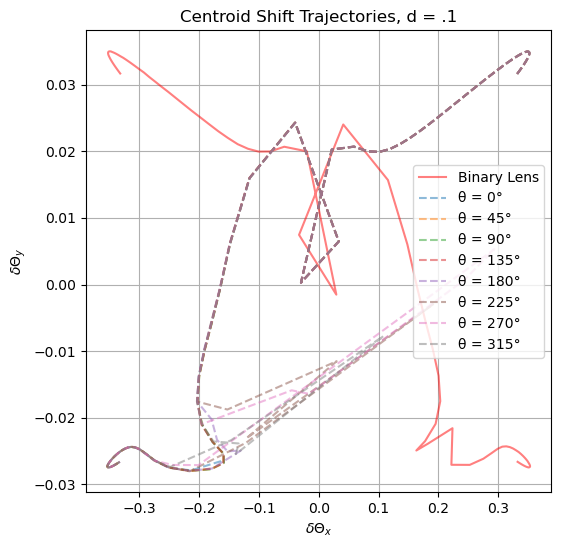

In [106]:
plt.figure(figsize=(6,6))

plt.plot(delta_x_two, delta_y_two, 'r-', label='Binary Lens', alpha = 0.5)


plt.plot(delta_x_three, delta_y_three, '--', label='θ = 0°', alpha = 0.5)
plt.plot(delta_x_three2, delta_y_three2, '--', label='θ = 45°', alpha = 0.5)
plt.plot(delta_x_three3, delta_y_three3, '--', label='θ = 90°', alpha = 0.5)
plt.plot(delta_x_three4, delta_y_three4, '--', label='θ = 135°', alpha = 0.5)
plt.plot(delta_x_three5, delta_y_three5, '--', label='θ = 180°', alpha = 0.5)
plt.plot(delta_x_three6, delta_y_three6, '--', label='θ = 225°', alpha = 0.5)
plt.plot(delta_x_three7, delta_y_three7, '--', label='θ = 270°', alpha = 0.5)
plt.plot(delta_x_three8, delta_y_three8, '--', label='θ = 315°', alpha = 0.5)


#plt.xlim(-.2,0)
#plt.ylim(-0.05,0.05)

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories, d = .1")
plt.grid(True)
plt.legend()
plt.show()

In [8]:
q_mult = 100 * q3
q_diff = q_mult/q2

In [9]:
q3 = q_mult

In [ ]:
ex1_m = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_1, 0, psi_1, rs, secnum, basenum, num_points)

param = [
    np.log(ex1_m.s2), np.log(ex1_m.q2), ex1_m.u0_list[0], ex1_m.alpha_deg,
    np.log(ex1_m.rho), np.log(ex1_m.tE), ex1_m.t0,
    np.log(ex1_m.s3), np.log(ex1_m.q3), ex1_m.psi_rad
]
mag, *_ = ex1_m.VBM.TripleLightCurve(param, ex1_m.highres_t)
three_system = ex1_m.systems[0]

delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

ex2 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_2, 0, psi_2, rs, secnum, basenum, num_points)

param = [
    np.log(ex2.s2), np.log(ex2.q2), ex2.u0_list[0], ex2.alpha_deg,
    np.log(ex2.rho), np.log(ex2.tE), ex2.t0,
    np.log(ex2.s3), np.log(ex2.q3), ex2.psi_rad
]
mag, *_ = ex2.VBM.TripleLightCurve(param, ex2.highres_t)

three_system2 = ex2.systems[0]

delta_x_three2 = three_system2['cent_x'] - three_system2['y1s']
delta_y_three2 = three_system2['cent_y'] - three_system2['y2s']

delta_x_three2 = - delta_x_three2
delta_y_three2 = delta_y_three2

ex3 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_3, 0, psi_3, rs, secnum, basenum, num_points)

param = [
    np.log(ex3.s2), np.log(ex3.q2), ex3.u0_list[0], ex3.alpha_deg,
    np.log(ex3.rho), np.log(ex3.tE), ex3.t0,
    np.log(ex3.s3), np.log(ex3.q3), ex3.psi_rad
]
mag, *_ = ex3.VBM.TripleLightCurve(param, ex3.highres_t)

three_system3 = ex3.systems[0]

delta_x_three3 = three_system3['cent_x'] - three_system3['y1s']
delta_y_three3 = three_system3['cent_y'] - three_system3['y2s']

delta_x_three3 = - delta_x_three3
delta_y_three3 = delta_y_three3

ex4 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_4, 0, psi_4, rs, secnum, basenum, num_points)

param = [
    np.log(ex4.s2), np.log(ex4.q2), ex4.u0_list[0], ex4.alpha_deg,
    np.log(ex4.rho), np.log(ex4.tE), ex4.t0,
    np.log(ex4.s3), np.log(ex4.q3), ex4.psi_rad
]
mag, *_ = ex4.VBM.TripleLightCurve(param, ex4.highres_t)

three_system4 = ex4.systems[0]

delta_x_three4 = three_system4['cent_x'] - three_system4['y1s']
delta_y_three4 = three_system4['cent_y'] - three_system4['y2s']

delta_x_three4 = - delta_x_three4
delta_y_three4 = delta_y_three4

ex5 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_5, 0, psi_5, rs, secnum, basenum, num_points)

param = [
    np.log(ex5.s2), np.log(ex5.q2), ex5.u0_list[0], ex5.alpha_deg,
    np.log(ex5.rho), np.log(ex5.tE), ex5.t0,
    np.log(ex5.s3), np.log(ex5.q3), ex5.psi_rad
]
mag, *_ = ex5.VBM.TripleLightCurve(param, ex5.highres_t)

three_system5 = ex5.systems[0]

delta_x_three5 = three_system5['cent_x'] - three_system5['y1s']
delta_y_three5 = three_system5['cent_y'] - three_system5['y2s']

delta_x_three5 = - delta_x_three5
delta_y_three5 = delta_y_three5

ex6 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_6, 0, psi_6, rs, secnum, basenum, num_points)

param = [
    np.log(ex6.s2), np.log(ex6.q2), ex6.u0_list[0], ex6.alpha_deg,
    np.log(ex6.rho), np.log(ex6.tE), ex6.t0,
    np.log(ex6.s3), np.log(ex6.q3), ex6.psi_rad
]
mag, *_ = ex6.VBM.TripleLightCurve(param, ex6.highres_t)

three_system6 = ex6.systems[0]

delta_x_three6 = three_system6['cent_x'] - three_system6['y1s']
delta_y_three6 = three_system6['cent_y'] - three_system6['y2s']

delta_x_three6 = - delta_x_three6
delta_y_three6 = delta_y_three6

ex7 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_7, 0, psi_7, rs, secnum, basenum, num_points)

param = [
    np.log(ex7.s2), np.log(ex7.q2), ex7.u0_list[0], ex7.alpha_deg,
    np.log(ex7.rho), np.log(ex7.tE), ex7.t0,
    np.log(ex7.s3), np.log(ex7.q3), ex7.psi_rad
]
mag, *_ = ex7.VBM.TripleLightCurve(param, ex7.highres_t)

three_system7 = ex7.systems[0]

delta_x_three7 = three_system7['cent_x'] - three_system7['y1s']
delta_y_three7 = three_system7['cent_y'] - three_system7['y2s']

delta_x_three7 = - delta_x_three7
delta_y_three7 = delta_y_three7

ex8 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_8, 0, psi_8, rs, secnum, basenum, num_points)

param = [
    np.log(ex8.s2), np.log(ex8.q2), ex8.u0_list[0], ex8.alpha_deg,
    np.log(ex8.rho), np.log(ex8.tE), ex8.t0,
    np.log(ex8.s3), np.log(ex8.q3), ex8.psi_rad
]
mag, *_ = ex8.VBM.TripleLightCurve(param, ex8.highres_t)

three_system8 = ex8.systems[0]

delta_x_three8 = three_system8['cent_x'] - three_system8['y1s']
delta_y_three8 = three_system8['cent_y'] - three_system8['y2s']

delta_x_three8 = - delta_x_three8
delta_y_three8 = delta_y_three8

: 

: 

: 

: 

In [ ]:
ex1_bin = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 0, t_lc= ex1_m.highres_t)
two_system = ex1_bin.systems[0]
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_y_two = - delta_y_two
delta_x_two = -delta_x_two

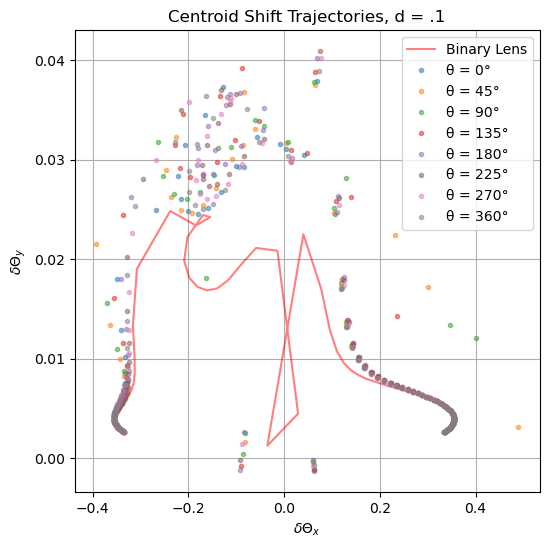

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(delta_x_two, delta_y_two, 'r-', label='Binary Lens', alpha = 0.5)


plt.plot(delta_x_three, delta_y_three, '.', label='θ = 0°', alpha = 0.5)
plt.plot(delta_x_three2, delta_y_three2, '.', label='θ = 45°', alpha = 0.5)
plt.plot(delta_x_three3, delta_y_three3, '.', label='θ = 90°', alpha = 0.5)
plt.plot(delta_x_three4, delta_y_three4, '.', label='θ = 135°', alpha = 0.5)
plt.plot(delta_x_three5, delta_y_three5, '.', label='θ = 180°', alpha = 0.5)
plt.plot(delta_x_three6, delta_y_three6, '.', label='θ = 225°', alpha = 0.5)
plt.plot(delta_x_three7, delta_y_three7, '.', label='θ = 270°', alpha = 0.5)
plt.plot(delta_x_three8, delta_y_three8, '.', label='θ = 360°', alpha = 0.5)


#plt.xlim(-.7,0)
#plt.ylim(-0.05,0.05)

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories, d = .1")
plt.grid(True)
plt.legend()
plt.show()